In [1]:
import os
os.environ['CONDA_DLL_SEARCH_MODIFICATION_ENABLE']="1"
import numpy as np
import pyswmm.toolkitapi as tkai
from pyswmm.simulation import Simulation

In [2]:
import matplotlib.pyplot as plt
import datetime

In [3]:
from swmm_api.input_file import read_inp_file
from pyswmm import Simulation,Links,Nodes,RainGages,SystemStats
from swmm_api.input_file.sections.others import TimeseriesData
from swmm_api.input_file.section_labels import TIMESERIES

C:\Users\chong\anaconda3\envs\py38\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
sim = Simulation('chaohu.inp')
sim.start()

In [5]:
time = sim._model.swmm_stride(300)

# depth flow rainfall read

In [102]:
nodes = Nodes(sim)
links = Links(sim)

In [109]:
print(nodes['JK-storage'].nodeid,nodes['JK-storage'].depth,nodes['CC-1'].total_outflow)
print(links['YS02001907YS02006553'].flow,links['YS02001649YS02001757'].flow,
      links['WS02006229WS02006228'].flow,links['WS02006115WS02006116'].flow,
      nodes['JK-storage'].statistics['flooding_volume'],nodes['JK-storage'].total_inflow )

JK-storage 2.9999999999999996 0.0
-0.0 0.0 0.0 0.0 0.0 0.0


In [14]:
rgs = RainGages(sim)

In [17]:
print(rgs['RG'].rainfall)

0.0


In [59]:
ns=[]
for n in Nodes(sim):
    ns.append(n.nodeid)

In [61]:
sum([nodes[n].statistics['flooding_volume'] for n in ns])

34.6131451416637

In [60]:
ns[0]

'HS02004478'

In [5]:
sim.close()

NameError: name 'sim' is not defined

# yaml test

In [90]:
text=''
for n in ns:
    text +=' '*6+'- !!python/tuple\n'+' '*8+'- "'+n+'"\n'+' '*8+'- flooding'+'\n'

In [91]:
f = open("test.txt",'w')
f.write(text)

10418

In [87]:
import yaml

In [94]:
config = yaml.load(open("chaohu.yaml"), yaml.FullLoader)

In [100]:
#config['states']
#config['action_assets']
#config['reward_targets']

In [35]:
config['action_assets']

['CC-R1', 'CC-R2', 'CC-S1', 'CC-S2', 'JK-R1', 'JK-R2', 'JK-S']

In [36]:
config['performance_targets']

[('T1', 'flooding'),
 ('T2', 'flooding'),
 ('T3', 'flooding'),
 ('T4', 'flooding'),
 ('T5', 'flooding'),
 ('CSO8', 'flooding'),
 ('CSO10', 'flooding'),
 ('T6', 'flooding'),
 ('CSO7', 'flooding'),
 ('CSO9', 'flooding'),
 ('C14', 'flow'),
 ('V1', 'flow'),
 ('V2', 'flow'),
 ('V3', 'flow'),
 ('V4', 'flow'),
 ('V5', 'flow'),
 ('V6', 'flow')]

# test

In [40]:
done = False
d2=[]
t=[]
t1 = sim._model.getCurrentSimulationTime()
while not done:
    #time = sim._model.swmm_step()
    time = sim._model.swmm_stride(300)
    nodes = Nodes(sim)
    #sim._model.setLinkSetting('JK-S', 0)
    t.append(time)
    d2.append(nodes['JK-storage'].depth)
    done = False if time > 0 else True

a=sim._model.getCurrentSimulationTime()
b=sim._model.getSimulationDateTime(tkai.SimulationTime.StartDateTime.value)
print((b - a).total_seconds()<=60)
sim._model.swmm_end()
sim._model.swmm_close()

In [7]:
class SWMM_ENV:
    #can be used for every SWMM inp
    def __init__(self,params):
        '''
        params: a dictionary with input
        orf: original file of swmm inp
        control_asset: list of contorl objective, pumps' name
        advance_seconds: simulation time interval
        flood_nodes: selected node for flooding checking
        '''
        self.params = params
    
    def reset(self,rain):
        inp = read_inp_file(self.params['orf']+'.inp')
        inp[TIMESERIES]['rainfall']=TimeseriesData(Name='rainfall',data=rain)
        inp.write_file(self.params['orf']+'_rain.inp')
        self.sim=Simulation(self.params['orf']+'_rain.inp')
        self.sim.start()
        
    def step(self,action):
        #获取模拟结果
        nodes = Nodes(self.sim)
        links = Links(self.sim)
        sys = SystemStats(self.sim)
        rgs = RainGages(self.sim)
        cum_inflow = 0
        cum_outfall = 0
        states=[nodes['JK-storage'].depth,nodes['CC-storage'].depth,nodes['XR-storage'].depth]
        
        #设置控制
        '''
        if actions is not None:
            if type(actions) == list or type(actions) == np.ndarray:
                for asset, a in zip(self.params['control_asset'], actions):
                    self.sim._model.setLinkSetting(asset, a)
            elif type(actions) == dict:
                for valve_position, asset in enumerate(actions):
                    self.sim._model.setLinkSetting(asset, a)
            else:
                raise ValueError("actions must be dict or list or np.ndarray \n got{}".format(type(actions)))
        '''
        for item,a in zip(self.params['control_asset'],action):
            links[item].target_setting = int(a)
        
        
        #模拟一步
        if self.params['advance_seconds'] is None:
            time = self.sim._model.swmm_step()
        else:
            time = self.sim._model.swmm_stride(self.params['advance_seconds'])
        done = False if time > 0 else True
        
        #获取reward
        flood = np.sum([nodes['JK-storage'].statistics['flooding_volume'],
                       nodes['CC-storage'].statistics['flooding_volume'],
                       nodes['XR-storage'].statistics['flooding_volume']])
        rewards = -flood
        '''
        if self.params['flood_nodes'] is not None:
            flood = [sum([nodes[n].statistics['flooding_volume'] for n in nodes])-cum_floods[j] for j,node in enumerate(self.flood_nodes)]           
            cum_floods = [sum([nodes[n].statistics['flooding_volume'] for n in node])for node in self.flood_nodes]
            rewards = [-fl/inflow for fl in flood]
        else:
            flood = routing['flooding'] - cum_floods
            cum_floods = routing['flooding']
            rewards = -flood/inflow
        '''
        
        if done:
            self.sim._model.swmm_end()
            self.sim._model.swmm_close()
        
        return states,actions,rewards,done
        
            
    

In [8]:
params={
    'orf':'chaohu',
    'control_asset':['CC-R1','CC-R2','CC-S1','CC-S2','JK-R1','JK-R2','JK-S','XR-1','XR-2','XR-3','XR-4'],
    'advance_seconds':300
}

In [9]:
env=SWMM_ENV(params)

In [10]:
#prepare rainfall
data=[]
for t in range(120):
    if t//60==0:
        data.append((datetime.datetime(2015, 8, 28, 9, np.mod(t,60)),0.1))
    elif t//60==1:
        data.append((datetime.datetime(2015, 8, 28, 10, np.mod(t,60)),0.1))

In [11]:
env.reset(data)

In [12]:
done = False
states,actions,rewards=[],[],[]
t=[]
while not done:
    action = [0.5 for _ in range(len(env.params['control_asset']))]
    s,a,r,done = env.step(action)
    states.append(s)
    actions.append(a)
    rewards.append(r)


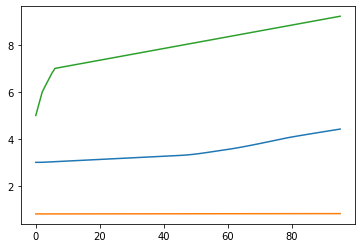

In [13]:
plt.plot(states)